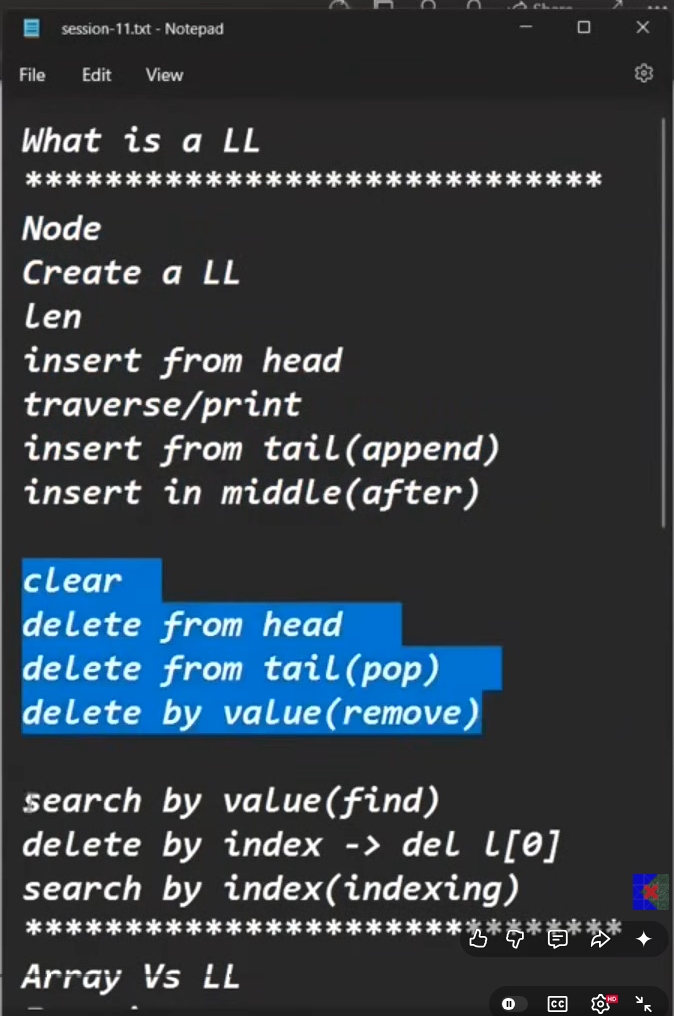

In [10]:
class Node:
###create a Node
    def __init__(self,value):
        self.value=value
        self.next=None


In [11]:
## Linked List class & Constructor

class LinkedList:
    def __init__(self,value):
        new_node=Node(value)
        self.head=new_node
        self.tail=new_node
        self.length=1


    def __str__(self):
        temp=self.head
        result=""
        while temp:
            result+=str(temp.value)+","
            temp=temp.next
        return "[]" if result=="" else "["+result[:-1].strip()+"]"

    def append(self,value):
        new_node= Node(value)

        ##1. if LL is empty, then the is new node will be the first node 
        ## Same a Node initialization,meaning head and tail will denote the first node only

        if self.head is None:
            self.head= new_node
            self.tail=new_node
        else:## 2 if not empty just add it to next of tail
            self.tail.next= new_node
            self.tail= new_node
            self.tail.next=None
        self.length+=1
        return True
    
    def pop(self):
        """
        Remove the last value and return it

        Point: Even though you have a self.tail pointer that tells you exactly where the last node is, you cannot easily remove it.
        To remove the last node, you must update the second-to-last node so its next pointer becomes None. 
        Because a singly linked list only points forward, you can't step backward from the tail to find that second-to-last node. 
        You still have to traverse the entire list starting from the head.
        
        """


        ##case 1: If list is empty:
        if self.length==0:
            return None
        ##case 2: if list has just one value , we need to make it empty list
        ##case 3 : if it has more the values,we will start from head and move till tail.next is none and r
        else:
            temp=self.head
            pre= temp
            while (temp.next):
                pre=temp
                temp=temp.next
            self.tail=pre
            self.tail.next=None
            self.length-=1
            if self.length==0:
                self.head=None
                self.tail=None

            return temp

    ##Adding and Removing at the Beginning        
    def prepend(self, value):
        #: If the list is empty, make sure you update both head and tail to point to the new node.
        new_node= Node(value)
        if self.length==0:
            self.head=new_node
            self.tail=new_node
        ## . Else make its next to head and move head to this new node
        else:
            new_node.next=self.head
            self.head=new_node
        self.length+=1
        return True
    

    def pop_first(self):
        ##if the list is empty:return None
        if self.length==0:
            return None
        # Standard removal step
        temp= self.head
        self.head=self.head.next
    
        temp.next=None# Disconnect the removed node
        self.length-=1

        if self.length==0: ## if list had just one value and it gets empty after above  operations
            self.tail=None# <-- Cleaning up the leftover tail pointer

        return temp
    ##2. Searching and Updating,These methods require you to traverse the list, so they take $O(n)$ time.
    def get_by_index(self,index):
        """Takes a number (index) and returns the node at that specific position.
        The Catch: Linked lists don't have built-in indexes like Python lists do.
        You have to write a loop that starts at head and steps forward index number of times. 
        Don't forget to check if the index is out of bounds (less than 0 or greater than/equal to self.length)!
        Note : our index here start at 0 not 1
        """
        if index>=self.length or index<0:
            return "Index Out of bound error"
        temp= self.head## already define it so we dont need to run index+1 times
        for _ in range(index):
            temp=temp.next
        return temp


    def set_value_by_index(self, index, value):
        """
        Finds the node at a specific index and changes its value.
        just use get(idnex)call
        """
        node= self.get(index)
        if node:
            node.value=value
            return True
        return False
    

    def get_by_value(self,value):
        
        for _ in range(self.length):
            temp=self.head
            if temp.value==value:
                return temp
        return "Value not found"

    ###Adding and Removing in the Middle
    def insert(self, index,value):
        """ 
        Creates a new node and inserts it at the specified index.

        Pro Tip: If the index is 0, just call your prepend method. If the index equals self.length, call append. Otherwise, 
        you'll need to use get() to find the node right before the insertion spot, and carefully rearrange the next pointers.
        """
        if index==0:
            self.prepend(value)
        elif index==self.length:
            self.append(value)
        else:
            new_ndoe= Node(value)
            temp=self.get_by_index(index)
            ##now we have temp after which we need to add nbew node
            ##save current next
            current_next= temp.next
            ##So set temp's next to this node
            temp.next= new_ndoe
            #point new added new  node next to current next to create full connection
            new_ndoe.next= current_next
        self.length+=1## dont forget
        return True
    

    def remove(self,index):

        """
        Removes and returns the node at the specified index.

        Pro Tip: Similar to insert, delegate to pop_first() if the index is 0, and pop() if the index is self.length - 1.   
        """
        if index==0:
            self.pop_first()
        elif index+1==self.length:
            self.pop()
        else:
            pre=self.get_by_index(index-1)
            ##now we need to remove this
            temp=pre.next
            #temp_next= temp.next
            pre.next=temp.next
            temp.next=None ## make temp totally detach from here
        self.length-=1
        return True
    



            












In [12]:
ll = LinkedList(7)
ll.append(15)
ll.append(22)
ll.append(12)
ll.append(55)

print(ll)
ll.pop()
print(ll)
ll.pop()
print(ll)


[7,15,22,12,55]
[7,15,22,12]
[7,15,22]


In [13]:
ll.prepend("xx")
print(ll)



[xx,7,15,22]


In [14]:
ll.pop_first()
print(ll)

[7,15,22]


In [15]:
ll.get_by_index(2).value

22

In [16]:
ll.get_by_index(0).value

7

In [17]:
ll.get_by_value(7).value

7

In [18]:
ll.get_by_value(14)

'Value not found'

In [19]:
4//2


2

In [20]:
5//2

2

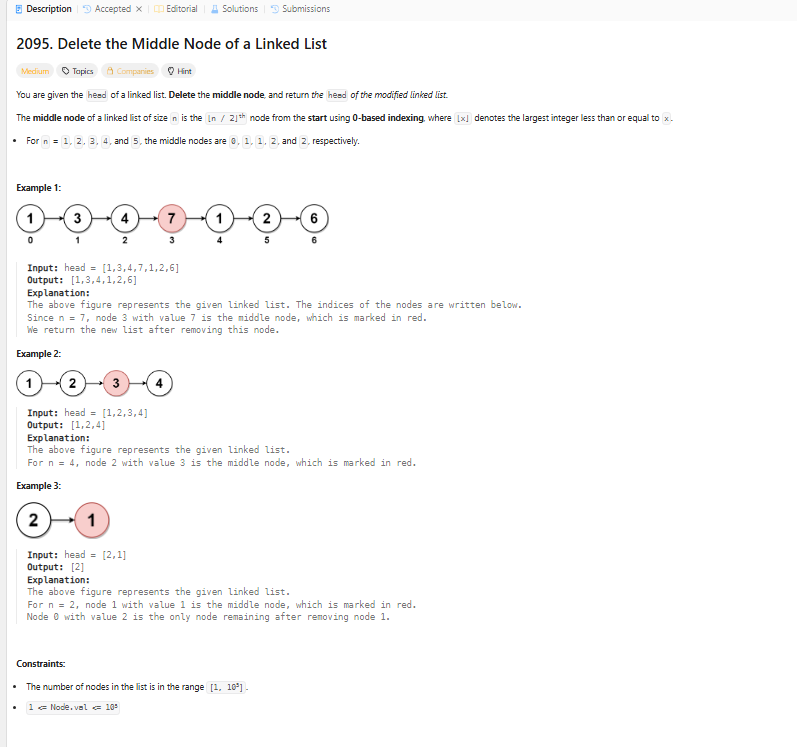

In [21]:
# Definition for singly-linked list.
from typing import Optional
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next
class Solution:
    def deleteMiddle(self, head: Optional[ListNode]) -> Optional[ListNode]:
        ##chek it has just one value
        if not head or head.next is None:
            return None

        current=head
        length=1
        while current.next:
            length+=1
            current=current.next
        if length==0:
            return None
        elif length==1:
            return None
        elif length==2:
           head.next=None
           return head
        else:
            mid_index=(length//2)
            print(length,mid_index)
            pre=head
            for _ in range(mid_index-1):
                pre=pre.next
            temp=pre.next
            pre.next=temp.next
            temp.next=None
            return head




        

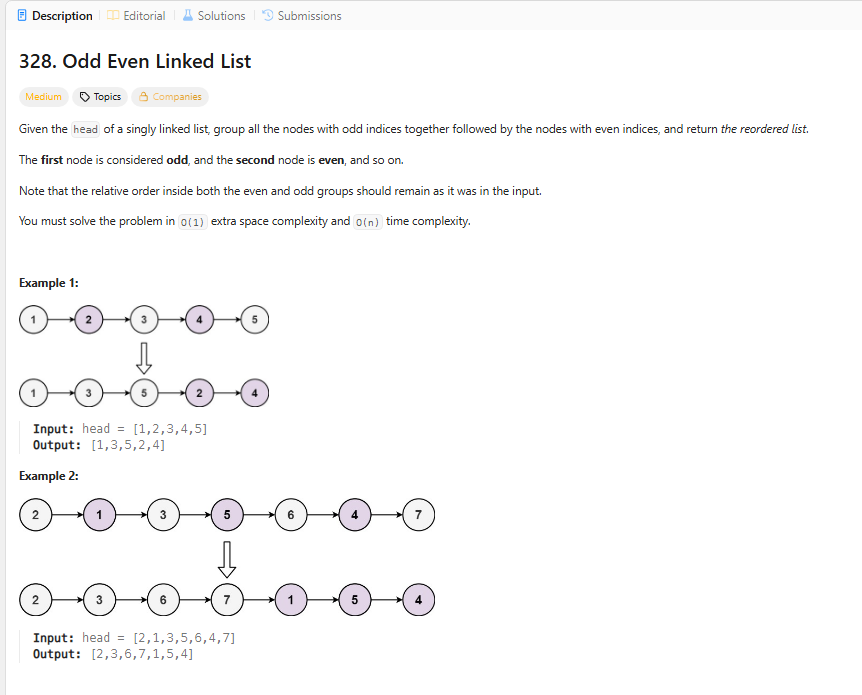

In [22]:
[(i+1)%2 for i in range(len([1,2,3,4,5,6,7]))]

[1, 0, 1, 0, 1, 0, 1]

In [ ]:
# Definition for singly-linked list.
from typing import Optional

class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next
class Solution:
    def oddEvenList(self, head: Optional[ListNode]) -> Optional[ListNode]:
        even_head=ListNode(0)##create empty LL for even and odd
        odd_head= ListNode(0)

        odd= odd_head
        even= even_head
        
        temp=head

        i=1
        while temp is not None:
            if i%2==1:
                odd.next=temp
                odd=odd.next
            else:
                even.next= temp
                even=even.next
            temp=temp.next
            i+=1
            
        odd.next=None
        even.next=None
        odd.next=even_head.next
        #return odd_head.next,even_head.next
        return odd_head.next
##bUt this is slow


In [ ]:
head = None
for i in [2,1,3,5,6,4,7][::-1]:##the first value will be at tail after inserting
    node = ListNode(i)
    node.next = head
    head = node

result = Solution().oddEvenList(head)

# print the linked list
cur = result
print("showing")
while cur is not None:
    print(cur.val, end=" -> ")
    cur = cur.next
print("None")


# odd, even = Solution().oddEvenList(head)

# # print the linked list
# cur = odd
# print("odd")
# while cur is not None :
#     print(cur.val, end=" -> ")
#     cur = cur.next

# cur = even
# print("\neven")
# while cur is not None :
#     print(cur.val, end=" -> ")
#     cur = cur.next




showing
2 -> 3 -> 6 -> 7 -> 1 -> 5 -> 4 -> None


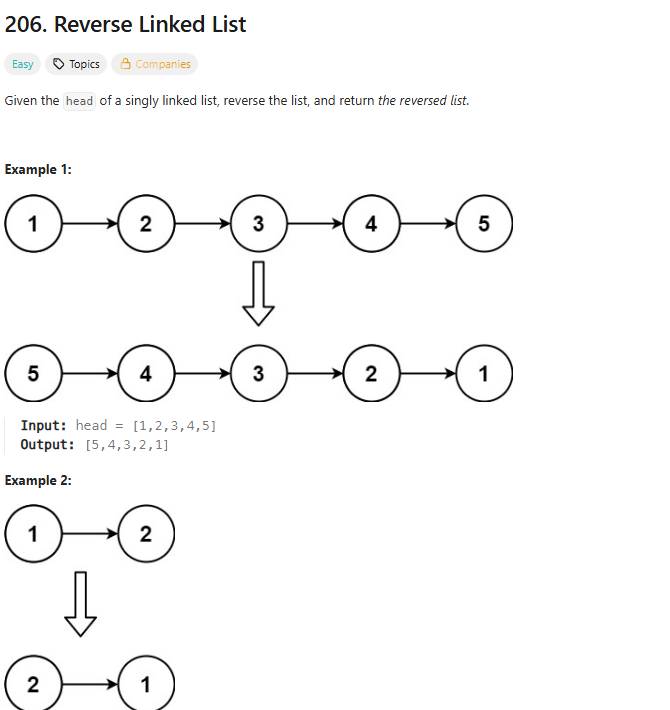

In [22]:
# Definition for singly-linked list.

from typing import Optional

class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next
class Solution:
    def reverseList(self, head: Optional[ListNode]) -> Optional[ListNode]:
        if not head or head.next is None:
            return head
        ##need to get the tail
        prev = None
        curr = head
        while curr is not None:
            nxt= curr.next
            curr.next=prev
            prev=curr
            curr=nxt

        return prev

        

In [23]:
head = None
for i in [1,2,3,4,5,6,7][::-1]:##the first value will be at tail after inserting
    node = ListNode(i)
    node.next = head
    head = node

result = Solution().reverseList(head)

# print the linked list
cur = result
print("showing")
while cur is not None:
    print(cur.val, end=" -> ")
    cur = cur.next
print("None")

showing
7 -> 6 -> 5 -> 4 -> 3 -> 2 -> 1 -> None


In [24]:
int("-"+str(1))

-1